# Predicting Irrigation Need 
**Name**: Ashish Ghimire

**Student ID**: 1002304752

**Professor**: Dr. Amir Farbin

**Course**: Python-II (DATA-3402)

**Competition Link:** https://www.kaggle.com/competitions/playground-series-s6e4/overview/prizes

## 1. Project Description

**Challenge Description:**
This project deals with the Kaggle competition on predicting irrigation needs for agricultural fields. Given environmental and agronomic features (soil properties, weather conditions, crop type, etc.), the goal is to classify each record into one of three irrigation need levels: **Low**, **Medium**, or **High**. 

**Dataset Description**
The dataset contains 630,000 records with 21 features, including both numeric measurements (soil moisture, temperature, rainfall) and categorical attributes (crop type, soil type, season). The target variable `Irrigation_Need` is multi-class with significant class imbalance.

## 2. Data Loading and Initial Look

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

In [2]:
dataset= pd.read_csv("Dataset/train.csv")
dataset

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,...,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,...,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,...,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,...,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low


In [3]:
# Shape of dataset
print(f"Dimension of the Dataset: {dataset.shape}")

Dimension of the Dataset: (630000, 21)


In [4]:
# Information (Name, Number of non-null values, and Data type) of each column in the dataset.
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [5]:
#Identifying ans storing the names of categorical and numeric attributes for future references. Workflow: Filter categorical/numeric attribtes, get its column names, and convert it into list

categorical_variables= dataset.select_dtypes(include='object').columns.to_list()
numeric_variables= dataset.select_dtypes(exclude='object').columns.to_list()
print(f"The categorical attributes of the dataset are:\n{categorical_variables}")
print(f"\n\nThe numeric attributes of the dataset are:\n{numeric_variables}")

The categorical attributes of the dataset are:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']


The numeric attributes of the dataset are:
['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


In [6]:
#Identifying number of missing values in each attribute

print(f"Total number of missing values in each attribute:\n{dataset.isnull().sum()}")

Total number of missing values in each attribute:
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


In [7]:
#Checking for any duplicate rows:
print(f"Number of duplicated rows: {dataset.duplicated().sum()}")

Number of duplicated rows: 0


In [8]:
# Statistical Summary Chart for numeric variables.
dataset[numeric_variables].describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [9]:
# Statistical Summary Chart for numeric variables.
dataset[categorical_variables].describe()

,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region,Irrigation_Need
count,630000,630000,630000,630000,630000,630000,630000,630000,630000
unique,4,6,4,3,4,4,2,5,3
top,Sandy,Sugarcane,Harvest,Kharif,Canal,Reservoir,No,South,Low
freq,166509,108910,167689,216561,161901,162994,316453,134809,369917


In [10]:
def outlier_value_sum_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    return len(outliers)

print("Number of Outliers in each Numeric Variables:\n")
for col in numeric_variables:
    print(f"{col} → Outliers: {outlier_value_sum_iqr(dataset, col)}")

Number of Outliers in each Numeric Variables:

id → Outliers: 0
Soil_pH → Outliers: 0
Soil_Moisture → Outliers: 0
Organic_Carbon → Outliers: 0
Electrical_Conductivity → Outliers: 0
Temperature_C → Outliers: 0
Humidity → Outliers: 0
Rainfall_mm → Outliers: 0
Sunlight_Hours → Outliers: 0
Wind_Speed_kmh → Outliers: 0
Field_Area_hectare → Outliers: 0
Previous_Irrigation_mm → Outliers: 0


In [11]:
# Generating a Overall Summary Chart of the Dataset: Includes Name, Type, Values(or Range), and Count.
summary={
    'Feature': [],
    'Type': [],
    "Total Count": [],
    'Sub-categories (or Range)': [],
    "Missing Values": [],
    "Total Outliers (IQR)": []
}
for col in dataset.columns:
    name= f"{col}".replace("_", " ")
    summary['Feature'].append(name)

    if col in numeric_variables:
        type= 'Numerical'
        summary['Type'].append(type)

        rng_val= f"{dataset[col].min()} - {dataset[col].max()}"
        summary['Sub-categories (or Range)'].append(rng_val)

        missing_vals= outlier_value_sum_iqr(dataset, col)
        summary['Total Outliers (IQR)'].append(int(missing_vals))

    else:
        type= "Categorical"
        summary['Type'].append(type)

        rng_val= dataset[col].unique().tolist()
        summary['Sub-categories (or Range)'].append(rng_val)

        summary['Total Outliers (IQR)'].append("N/A")
    
    cnt= len(dataset[col])
    summary["Total Count"].append(cnt)
    missing_vals= dataset[col].isnull().sum()
    summary["Missing Values"].append(missing_vals)

There are various ways of identifying/detect outliers that are present in a dataset, with IQR method being one of them. In this method, we tend to find out the `upper whisker` and `lower whisker` using the formula :
<center>Upper Whisker= Q<sub>3</sub> + 1.5 * IQR, and</center>
<center>Lower Whisker= Q<sub>1</sub> - 1.5 * IQR</center>

where Q<sub>1</sub>, Q<sub>3</sub>, and IQR are the First Quartile, Third Quartile, and Inter Quartile Range respectively.
Any values that lie outside the range of these whiskers will automatically count as an outlier by this method. While this method was implemented into the dataset, **no outliers** could be detected in this dataset.

In [12]:
pd.DataFrame.from_dict(summary)

,Feature,Type,Total Count,Sub-categories (or Range),Missing Values,Total Outliers (IQR)
0,id,Numerical,630000,0 - 629999,0,0
1,Soil Type,Categorical,630000,"[Loamy, Clay, Sandy, Silt]",0,N/A
2,Soil pH,Numerical,630000,4.8 - 8.2,0,0
3,Soil Moisture,Numerical,630000,8.0 - 64.99,0,0
4,Organic Carbon,Numerical,630000,0.3 - 1.6,0,0
5,Electrical Conductivity,Numerical,630000,0.1 - 3.5,0,0
6,Temperature C,Numerical,630000,12.0 - 42.0,0,0
7,Humidity,Numerical,630000,25.0 - 94.99,0,0
8,Rainfall mm,Numerical,630000,0.38 - 2499.69,0,0
9,Sunlight Hours,Numerical,630000,4.0 - 11.0,0,0


In [13]:
#Identifying the Distribution Imbalance in the categorical data.

print("Percentage distribution of each category")
for col in categorical_variables:
    print(f"\n\nFor {col}")
    unique_values= dataset[col].unique().tolist()
    for val in unique_values:
        perc_conc= len(dataset[dataset[col]==val])/len(dataset) * 100
        print(f"{val}: {perc_conc:.2f}%")

Percentage distribution of each category


For Soil_Type
Loamy: 24.83%
Clay: 25.15%
Sandy: 26.43%
Silt: 23.58%


For Crop_Type
Sugarcane: 17.29%
Wheat: 16.35%
Rice: 16.94%
Potato: 16.26%
Cotton: 16.61%
Maize: 16.55%


For Crop_Growth_Stage
Sowing: 23.41%
Vegetative: 24.96%
Flowering: 25.01%
Harvest: 26.62%


For Season
Zaid: 32.60%
Kharif: 34.37%
Rabi: 33.02%


For Irrigation_Type
Drip: 23.98%
Rainfed: 24.70%
Sprinkler: 25.62%
Canal: 25.70%


For Water_Source
Rainwater: 24.29%
River: 25.37%
Reservoir: 25.87%
Groundwater: 24.47%


For Mulching_Used
No: 50.23%
Yes: 49.77%


For Region
East: 20.03%
South: 21.40%
North: 18.12%
West: 20.82%
Central: 19.64%


For Irrigation_Need
Low: 58.72%
Medium: 37.95%
High: 3.33%


## Classical Imbalance
This is a **multi-class classification problem** with a noticable class imbalance in the target variable `Irrigation_Need`

| Class  | Percentage |
|--------|------------|
| Low    | 58.72%     |
| Medium | 37.95%     |
| High   | 3.33%      |

The **High** class is severely underpresented at only 3.33% of the data. This means a general model could achieve ~96% accuracy by simply never predicting "high", which would be highly misleading. To address this, we will apply `class_weight='balanced'` in our classifier model, which penalizes misclassification of minority classes more heavily during training.


## Target Variable Encoding

The target variable `Irrigation_Need` is encoded as **string labels**: `'Low'`, `'Medium'`, and `'High'`. Unlike binary classification where targets are typically encoded as `0` and `1`, this is a 3-class problem with no inherent numeric ordering. The labels will be passed directly to the classifier — scikit-learn's `RandomForestClassifier` handles string labels natively without requiring manual numeric encoding.

## Section Summary

| Property | Finding |
|----------|---------|
| Total Records | 630,000 |
| Total Features | 21 (9 categorical, 11 numerical) |
| Missing Values | None |
| Duplicate Rows | None |
| Outliers (IQR) | None detected |
| Target Variable | `Irrigation_Need` (Low / Medium / High) |
| Class Imbalance | Yes — High class only 3.33% |

The dataset is clean and complete, requireing no imputations and duplicate removal. The primamry concern for modeling is the class imbalance in the target variable, whcih will be addressed during the machine learning phase.

## 3. Data Visualization

For this **multi-class classification task**, we compare the distribution of each feature across three `Irrigation_Need` classes: Low, Medium, and High 
- **Numerical features**: Density histograms and box plots per class
- **categorical features**: Row-normalizes cross-tabulation tables, as bar charts are less informative for discrete variables with many sub-categories 

The goal is to identify which features show meaningful separation between classes, as those will likely be the strongest predictors for our model.

### Raw Feature Distribution 
First, we examine the raw distribution of each numeric feature to understand their shape, range, and skewness- independent of class labels.

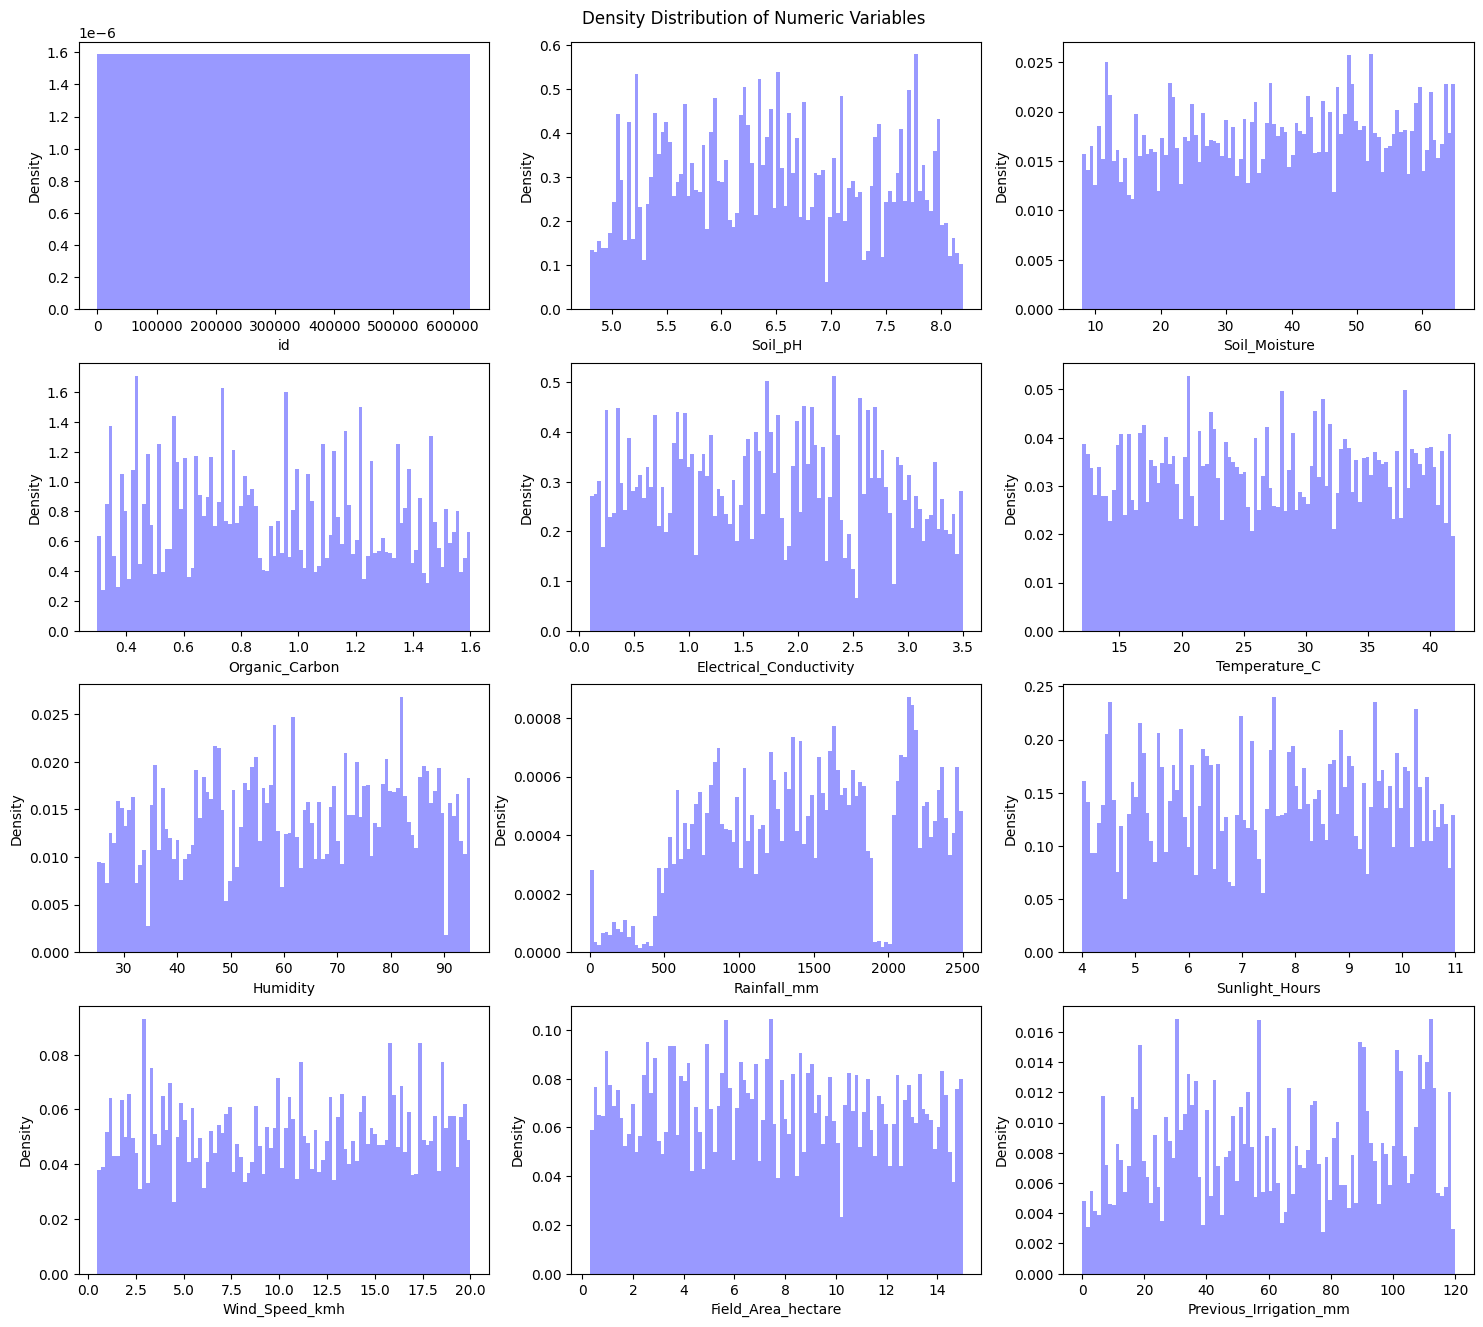

In [14]:
# Feature Distribution
n_cols= 3
n_rows = int(np.ceil(len(numeric_variables) / n_cols))
fig, axes= plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))
axes= axes.flatten()
for idx, var in enumerate(numeric_variables):
    ax=axes[idx]
    ax.hist(dataset[var], bins=100, density=True, color='blue', alpha= 0.4)
    ax.set_xlabel(f"{var}")
    ax.set_ylabel(f"Density")
plt.suptitle("Density Distribution of Numeric Variables", y=0.9)
plt.show()

Key Takeaways:

- None of the features are normally distributed. All features exhibit either uniform, noisy-flat, or irregular distributions. Normality-based assumptions should not be applied.
- `Rainfall_mm` is the only notably skewed feature — it is left-skewed (negatively skewed), with values concentrated in the 1000–2000 mm range and very few observations below 500 mm.
- Feature ranges vary drastically — from `Sunlight_Hours` (3–11) to `Rainfall_mm` (0–2500), making feature scaling mandatory before training any distance-based or gradient-based model.
- `id` must be dropped — it is a sequential index with no predictive value.
- `Soil_pH`, `Electrical_Conductivity`, and `Previous_Irrigation_mm` show notably high bin-to-bin noise and should be inspected for outliers using box plots before modeling.

### Numeric Features vs Target Class
We now overlay the distribution of each numeric feature separated by the `Irrigation_Need` class to identify which features separate the classes most clearly.

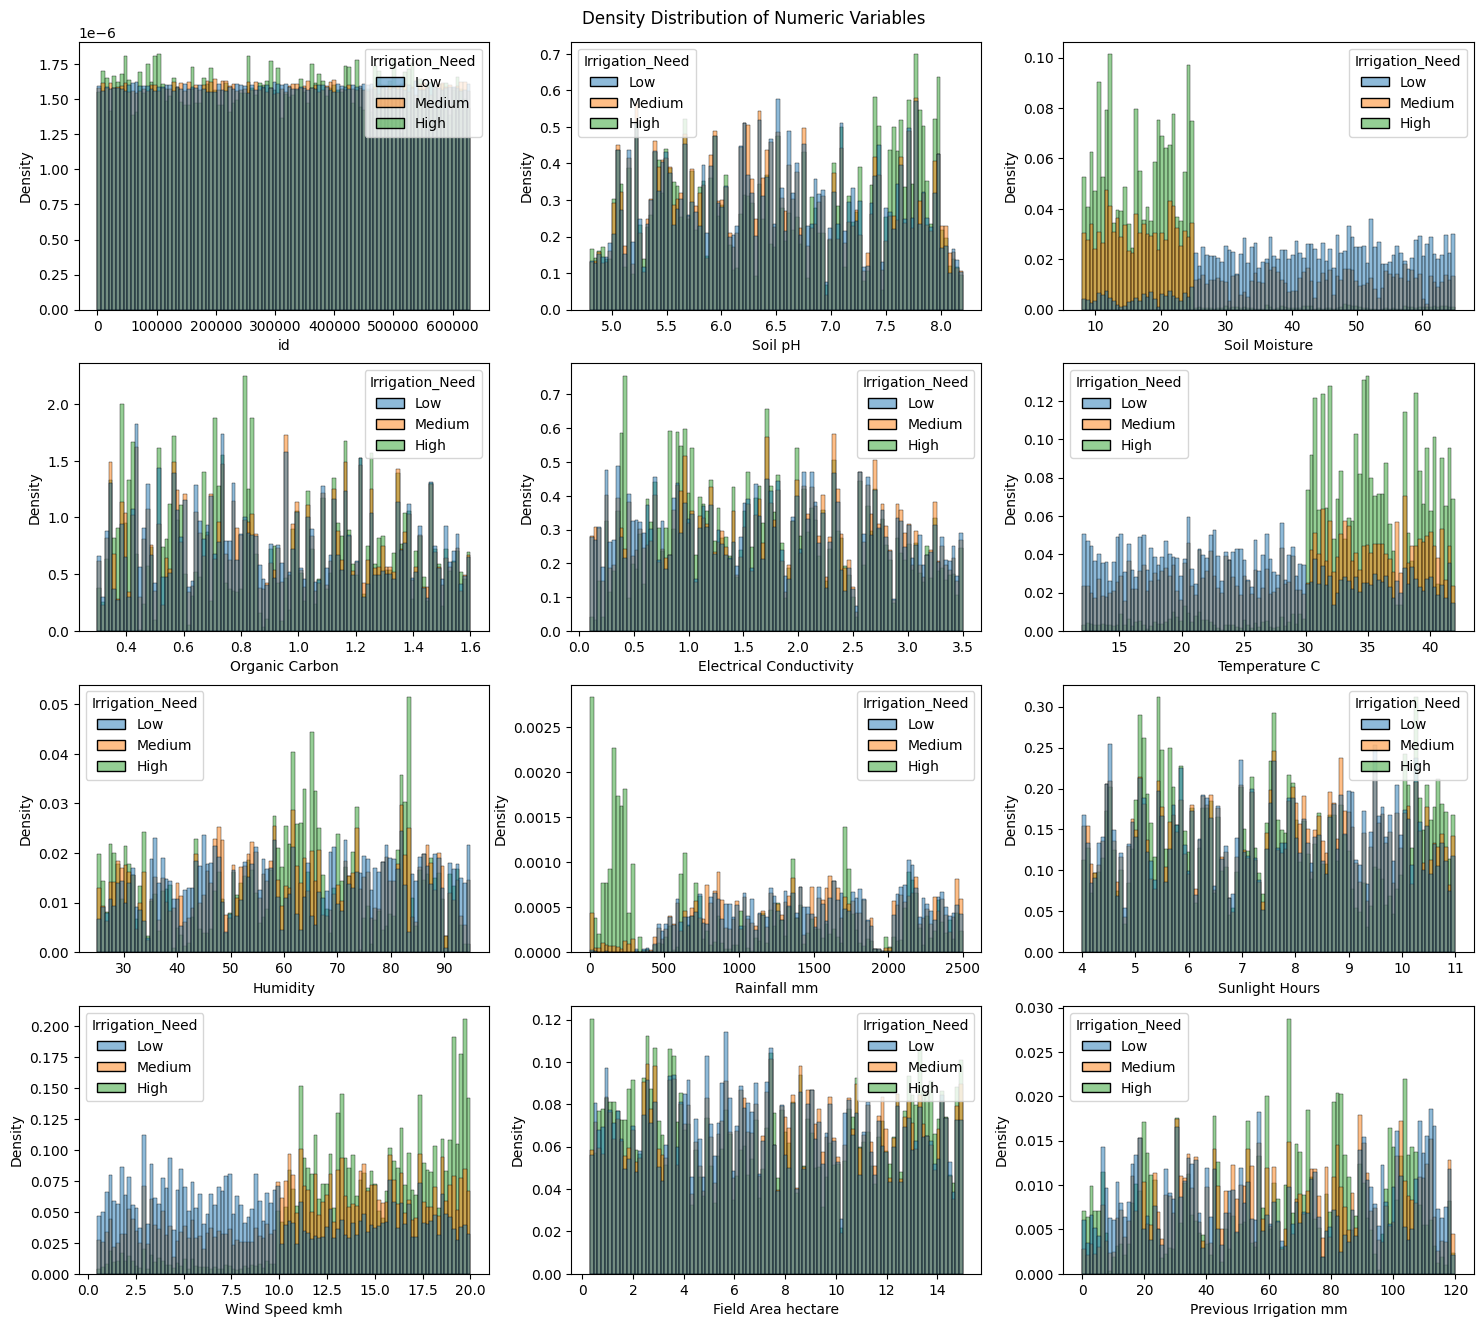

In [15]:
# Feature Distribution
n_cols= 3
n_rows = int(np.ceil(len(numeric_variables) / n_cols))
fig, axes= plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))
axes= axes.flatten()
for idx, var in enumerate(numeric_variables):
    ax=axes[idx]
    sns.histplot( data=dataset, x=var, hue="Irrigation_Need", bins=100, stat="density", common_norm=False, ax=ax)
    ax.set_xlabel(f"{var.replace("_", " ")}")
    ax.set_ylabel(f"Density")
plt.suptitle("Density Distribution of Numeric Variables", y=0.9)
plt.show()

Key Takeaways:
- `Soil_Moisture` and `Temperature_C` are the two strongest features for 
  separating irrigation need classes, as they show clear and consistent 
  class separation.
- `Rainfall_mm` shows moderate discriminating power, but alone cannot 
  cleanly separate all three classes.
- The remaining features show heavy class overlap and are unlikely to be 
  strong individual predictors.

Overall, the fact that only 2 features show meaningful class separation 
suggests that the model will need to learn from combinations of features 
rather than relying on single-features alone.

### Box Plots by Class
Box plots complement the histograms above by clearly showing median shifts and spread differences across classes, and help surface any class-specific outliers.

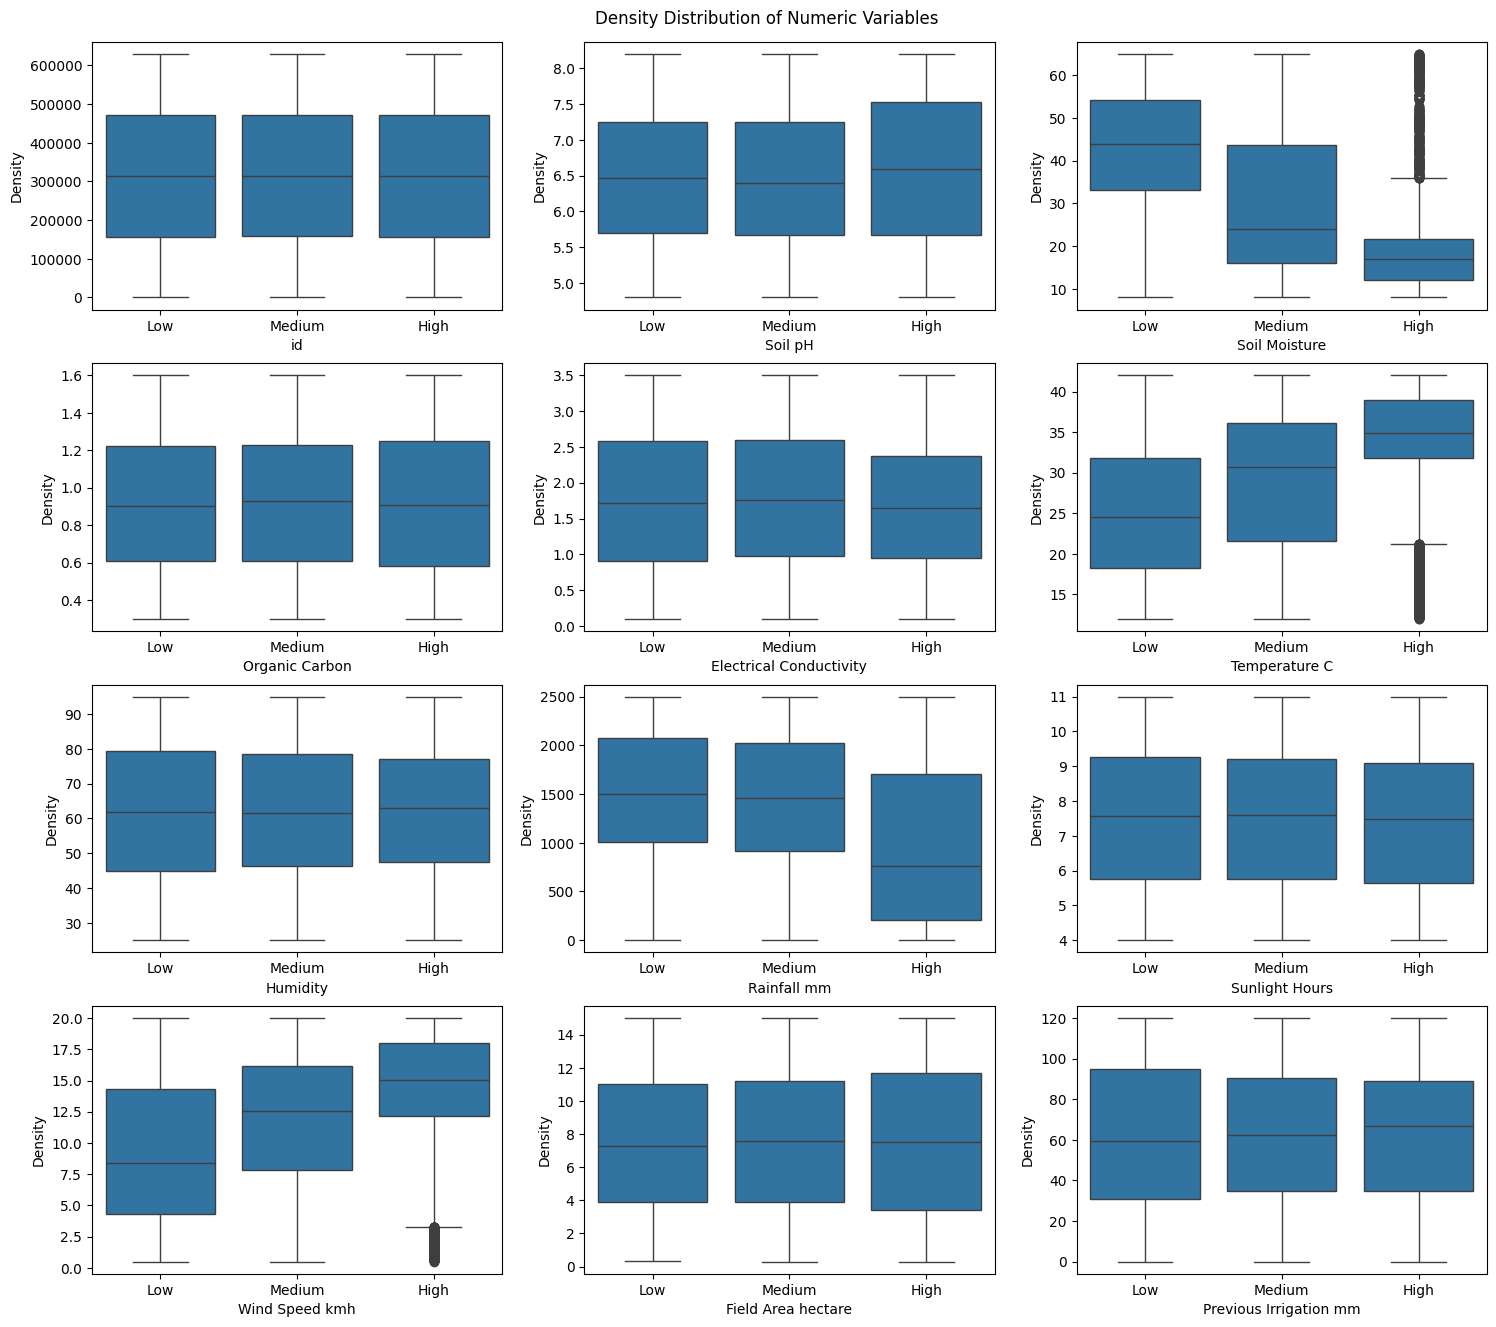

In [16]:
# Feature Distribution
n_cols= 3
n_rows = int(np.ceil(len(numeric_variables) / n_cols))
fig, axes= plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))
axes= axes.flatten()
for idx, var in enumerate(numeric_variables):
    ax=axes[idx]
    sns.boxplot( data=dataset, x="Irrigation_Need", y= var, ax=ax)
    ax.set_xlabel(f"{var.replace("_", " ")}")
    ax.set_ylabel(f"Density")
plt.suptitle("Density Distribution of Numeric Variables", y=0.9)
plt.show()

**Key Insights**
- Soil_Moisture and Temperature_C are confirmed as the primary predictors — they show the cleanest, most monotonic median shifts across all three irrigation need classes.
- Rainfall_mm is a secondary predictor, particularly effective at identifying the High irrigation need class.
- Wind_Speed_kmh offers a weak but consistent trend and may contribute marginally in ensemble models.
- Soil_pH, Organic_Carbon, Electrical_Conductivity, Humidity, Sunlight_Hours, and Field_Area_hectare show no meaningful class separation and are unlikely to contribute individually. They may still be retained for tree-based models and let feature importance decide their fate.
- The outliers in Wind_Speed_kmh (High class) should be investigated before training.

C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


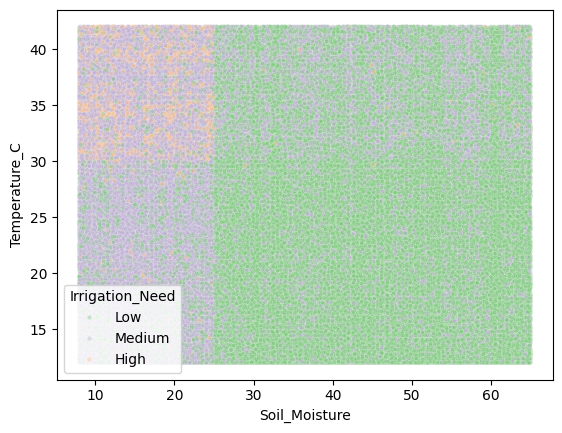

In [17]:
sns.scatterplot(data=dataset, x='Soil_Moisture', y='Temperature_C', hue='Irrigation_Need', palette='Accent', s=10, alpha=0.4)
plt.show()

Even with two of the most important features combined, there is still large overlapp between low and medium across the entire plot. This suggests that the classes are not linearly separable and will need some non-linear model to handel the classification better.

<Axes: >

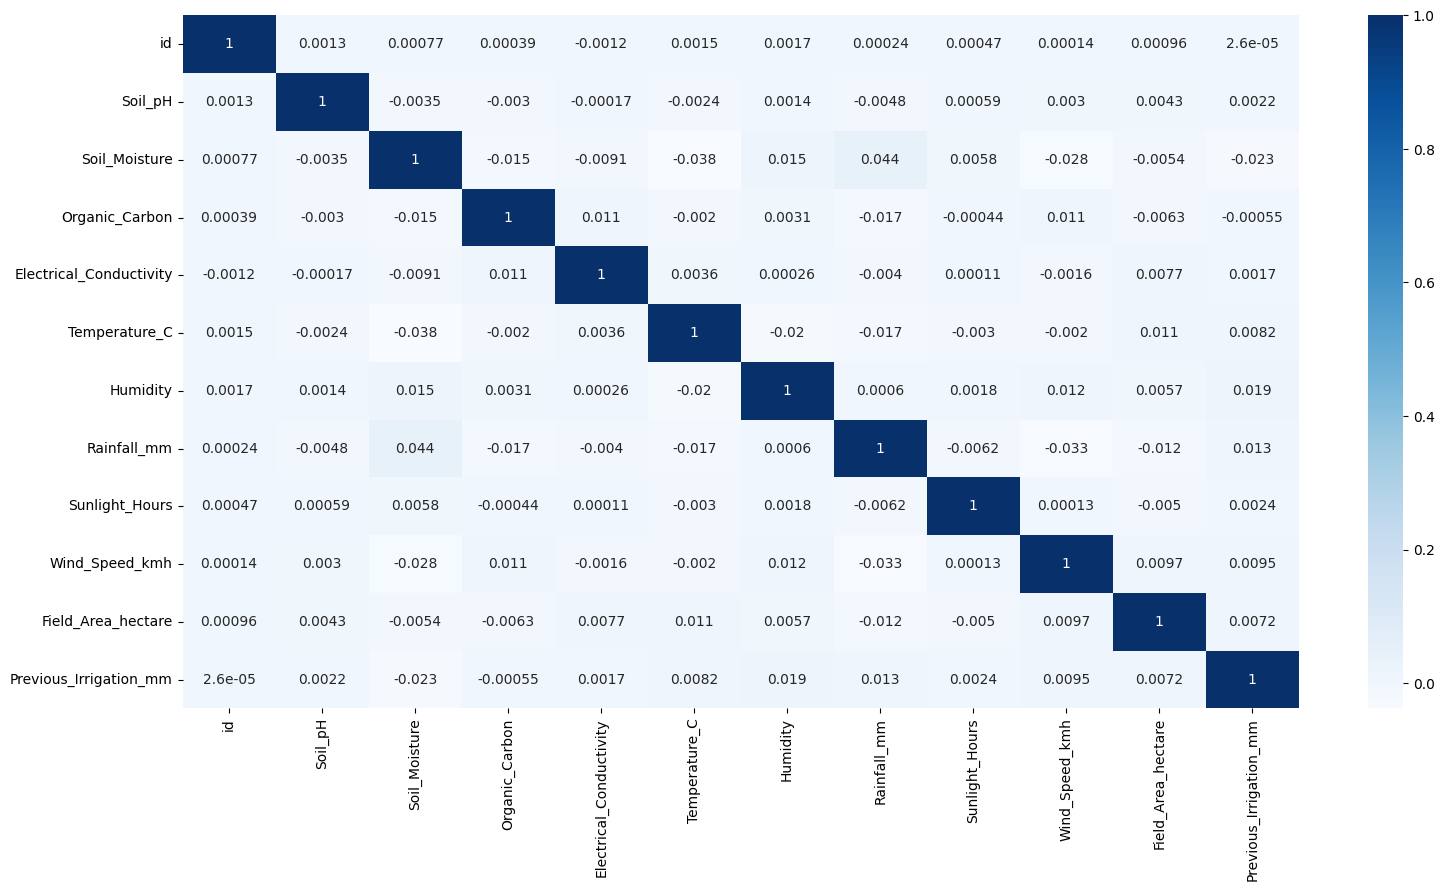

In [18]:
plt.figure(figsize=(18,9))
sns.heatmap(data=dataset[numeric_variables].corr(),cmap='Blues', antialiased=True, annot=dataset[numeric_variables].corr())

No linear correlation between the features can be observed. This confirms the need of non-linear model for better performance.

### Categorical Features vs Target Class
For categorical features, bar charts of raw counts are misleading due to class imbalance in the target. Instead, we use **row-normalized cross-tabulation tables**, which show the *percentage* of each irrigation class within every sub-category, making comparisons fair regardless of category size.

In [19]:
categorical_variables.remove("Irrigation_Need")

In [20]:
for col in categorical_variables:
    ct = (pd.crosstab(dataset[col], dataset['Irrigation_Need'], normalize='index') * 100).round(2)
    ct.index.name = col
    ct.columns.name = 'Irrigation_Need'
    print(f"\n=== {col} ===")
    display(ct)


=== Soil_Type ===


Irrigation_Need,High,Low,Medium
Soil_Type,,,
Clay,3.51,58.70,37.80
Loamy,2.88,59.93,37.19
Sandy,3.87,57.63,38.50
Silt,3.03,58.68,38.29



=== Crop_Type ===


Irrigation_Need,High,Low,Medium
Crop_Type,,,
Cotton,3.61,58.72,37.67
Maize,4.22,57.01,38.77
Potato,2.74,57.59,39.67
Rice,2.34,59.99,37.68
Sugarcane,3.92,59.29,36.80
Wheat,3.17,59.65,37.18



=== Crop_Growth_Stage ===


...

Irrigation_Need,High,Low,Medium
Water_Source,,,
Groundwater,2.35,60.10,37.55
Rainwater,3.35,60.37,36.28
Reservoir,3.26,56.26,40.47
River,4.34,58.30,37.35



=== Mulching_Used ===


Irrigation_Need,High,Low,Medium
Mulching_Used,,,
No,5.85,44.50,49.64
Yes,0.79,73.06,26.15



=== Region ===


Irrigation_Need,High,Low,Medium
Region,,,
Central,3.44,59.30,37.26
East,2.87,59.35,37.78
North,3.43,57.63,38.95
South,3.48,58.65,37.87
West,3.46,58.58,37.96


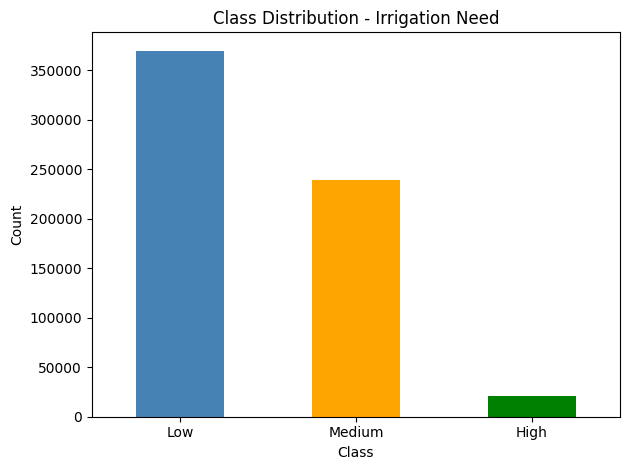

In [23]:
# Class Disrtibution for Irrigation Need
dataset["Irrigation_Need"].value_counts().plot(kind='bar', color=['steelblue', 'orange', 'green'])
plt.title('Class Distribution - Irrigation Need')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### Key Insights

Before analyzing relationships with the target, the distribution of categorical features was observed to understand the class balance.  

Most features, such as Soil_Type, Crop_Type, Season, Irrigation_Type, and Water_Source, are **nearly uniformly distributed**, indicating no strong imbalance across categories. However, a **classical imbalance** was found for the target variable, where the High class is significantly underrepresented (3.33%)  

On the other hand, Row-wise crosstabs show how irrigation needs vary within each category. Most of the categorical features (Soil Type, Crop Type, Season, etc.) show very similar `Low Irrigation Need` dominated distributions, indicating weak influence on the target.  

However, **Crop Growth Stage** and **Mulching Used** show strong variation, suggesting them as important variables for predicting irrigation need.

### Most Promising Features for Machine Learning
Based on the visualizations above, the following features show the strongest class separation and are expected to be most useful for the model:
| Feature | Type | Reason |
|---------|------|--------|
| `Soil_Moisture` | Numerical | Clearest monotonic separation across all 3 classes |
| `Temperature_C` | Numerical | Strong and consistent median shift per class |
| `Rainfall_mm` | Numerical | Effective at identifying the High class |
| `Crop_Growth_Stage` | Categorical | Strong variation in irrigation need across stages |
| `Mulching_Used` | Categorical | Observable difference in class distribution |
| `Wind_Speed_kmh` | Numerical | Weak but consistent trend across classes |

Features such as `Soil_pH`, `Organic_Carbon`, `Electrical_Conductivity`, 
`Humidity`, `Sunlight_Hours`, and `Field_Area_hectare` show heavy class overlap and are unlikely to be strong individual predictors. However, these features will be kept, and the model's feature importance will decide their fate

# Data Cleaning and Preparation for Machine Learning
The dataset was found to be clean: no missing values, no duplicates, and no outliers were detected. However, the following preparation steps are required before training:
1. **Feature Scaling**: Numeric features have vastly different ranges and must be standardized
2. **One-hot encoding**: categorical features must be converted to a numeric format 
3. **Dropping unnecessary columns**: `id` has no predictive value and must be removed
4. **Addressing class imbalance**: `High` class (3.33%) is severely underrepresented

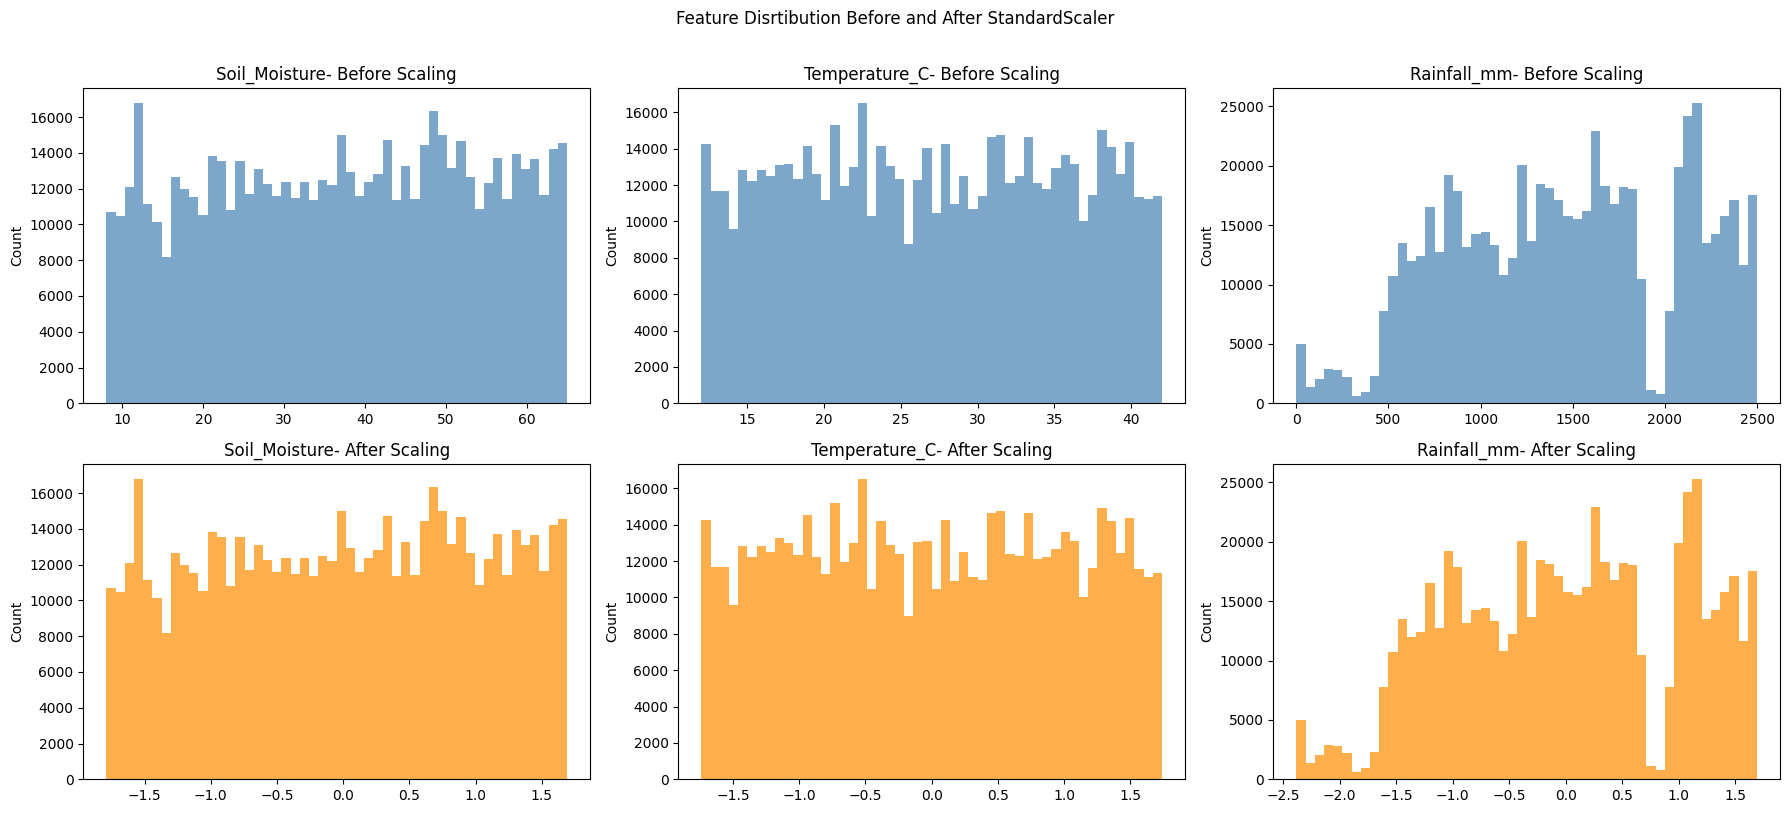

In [24]:
# Demonstration of Scaling
from sklearn.preprocessing import StandardScaler

# Selecting a few representing features (numeric) for visualization
features_to_show= ['Soil_Moisture', 'Temperature_C', 'Rainfall_mm']
scaler= StandardScaler()
scaled_values= scaler.fit_transform(dataset[features_to_show])

fig, axes= plt.subplots(2,3, figsize=(18,8))

for i, feature in enumerate(features_to_show):
    #Before Scaling
    axes[0,i].hist(dataset[feature], bins=50, color='Steelblue', alpha=0.7)
    axes[0,i].set_title(f"{feature}- Before Scaling")
    axes[0,i].set_ylabel("Count")

    #After Scaling
    axes[1,i].hist(scaled_values[:, i], bins=50, color='darkorange', alpha=0.7)
    axes[1,i].set_title(f"{feature}- After Scaling")
    axes[1,i].set_ylabel("Count")

plt.suptitle("Feature Disrtibution Before and After StandardScaler", y=1.01)
plt.tight_layout()
plt.show()

### Observations- Scaling
`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**. This preserves the *shape* of each distribution, as it only shifts the range without changing the underlying distribution of every feature. This is important because our earlier observations about skewness and class separation still hold after scaling. 

This step is critical here because features like `Rainfall_mm` (range 0-2500) and `Sunlight_Hours` (range: 3-11) differ drastically in scale, which would bias distance-based and gradient-based models without normalization

In [25]:
# Demonstration of One-Hot Encoding on a sample
sample = dataset[categorical_variables].head(5)
encoded_sample = pd.get_dummies(sample)
print("Before One-Hot Encoding:")
display(sample)
print("\nAfter One-Hot Encoding:")
display(encoded_sample)

Before One-Hot Encoding:


,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
0,Loamy,Sugarcane,Sowing,Zaid,Drip,Rainwater,No,East
1,Clay,Wheat,Vegetative,Kharif,Rainfed,River,Yes,South
2,Clay,Rice,Vegetative,Kharif,Sprinkler,Reservoir,Yes,North
3,Sandy,Wheat,Flowering,Kharif,Canal,River,Yes,South
4,Clay,Wheat,Sowing,Rabi,Canal,River,No,South



After One-Hot Encoding:


,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,Crop_Growth_Stage_Flowering,Crop_Growth_Stage_Sowing,Crop_Growth_Stage_Vegetative,Season_Kharif,...,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_East,Region_North,Region_South
0,False,True,False,False,True,False,False,True,False,False,...,False,False,True,False,False,True,False,True,False,False
1,True,False,False,False,False,True,False,False,True,True,...,True,False,False,False,True,False,True,False,False,True
2,True,False,False,True,False,False,False,False,True,True,...,False,True,False,True,False,False,True,False,True,False
3,False,False,True,False,False,True,True,False,False,True,...,False,False,False,False,True,False,True,False,False,True
4,True,False,False,False,False,True,False,True,False,False,...,False,False,False,False,True,True,False,False,False,True


### One-Hot Encoding- Observations
Categorical features are converted into binary (0/1) columns- one per unique category. This allows the model to interpret categorical data numerically without considering any false ordinal relationships between/within categories. In the full pipeline, this is handled automatically via scikit-learn's `OneHotEncoder` with `handle_unknown='ignore'` to gracefully handle any unseen categories in the test set.

### Addressing Class Imbalance 
The target variable `Irrigation_Need` has a significant class imbalance:
- Low; 58.72%
- Medium: 37.95%
- High: 3.33%

Rather than resampling the dataset, we use `class_weight='balanced'` in our `RandomForestClassifier`. This automatically adjusts the weight of each class inversely proportional to its frequency, penalizing misclassification of the minority class (`High`) more heavily during training- without altering the dataset itself.

In [26]:
#Removing the unnecessary columns:

# Removing id as it has ho predictive value
numeric_variables.remove('id')

## Machine Learning

### Problem Formulation
- **Target variables:** `Irrigation_Need` (string labels: Low / Medium / High)
- **Dropped Columns** `id` (sequential row identifier with no predictive value)
- **Categorical Encoding**: One-hot encoding via `ColumnTransformer.` 
- **Numerical Scaling**: `StandardScaler` applied to all numeric features
- **Class imbalance**: Handeled via `class_weight='balanced'`
- **Algorithm**: `RandomForestClassifier` (chosen because it is a non-linear tree-based model, and handles multi-class classification natively) 
- **Split**: 70% train / 15% validation / 15% test, stratified by target class

In [27]:
# Creating a pipeline for model:

#Split the data
X = dataset.drop('Irrigation_Need', axis=1)
y = dataset['Irrigation_Need']

# First split off 30% as temp (will become val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Split temp evenly into validation and test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train size:      {X_train.shape[0]:,}")
print(f"Validation size: {X_val.shape[0]:,}")
print(f"Test size:       {X_test.shape[0]:,}")

Train size:      441,000
Validation size: 94,500
Test size:       94,500


### Training the Model
We use a `RandomForestClassifier` wrapped in a full sklearn `Pipeline` that handles preprocessing and classification in a single object. This prevents data leakage by ensuring the scaler is fit only on training data.

In [28]:
preprocessor= ColumnTransformer([
    ('num', StandardScaler(), numeric_variables),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_variables)
])

#Full Pipeline
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2, min_samples_split=5, max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1))
])

#Train
model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


### Evaluation on Validation Set
We evaluate on the **Validation Set** to measure the performance during the model training phase. The test is held out until the very end to prevent overfitting and leakage.

In [29]:
y_pred_val= model.predict(X_val)
print("Validation Set Performance")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_val, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_val, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_val, average='weighted'):.4f}")

Validation Set Performance
Accuracy: 0.9856
Precision: 0.9855
Recall: 0.9856
F1 Score: 0.9855


In [30]:
# Confusion Matrix on Validation Set
cm= confusion_matrix(y_val, y_pred_val)
cm_df = pd.DataFrame(
    cm,
    index=['Actual_Low', 'Actual_Medium', 'Actual_High'],
    columns=['Pred_Low', 'Pred_Medium', 'Pred_High']
)
cm_df

,Pred_Low,Pred_Medium,Pred_High
Actual_Low,2885,0,267
Actual_Medium,0,55241,246
Actual_High,95,757,35009


**Observations- Validation Performance**
- **Accuracy** alone is misleading here due to class imbalance- a model predicting only "Low" would achieve ~58% accuracy. 
- **Weighted F1** is the most informative metric as it accounts for both precision and recall scores across all classes, weighted by class frequency. 
- The confusion matrix reveals how well the model handles the minority `High` class, which is the most critical class to get right.

### Final Evaluation on Test Set
The test set is used **Only once** after all modeling decisions have been finalized for getting an unbiased estimate of real-world performance.

In [31]:
y_pred_test= model.predict(X_test)
print("Test Set Performance")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_test, average='weighted'):.4f}")

Test Set Performance
Accuracy: 0.9858
Precision: 0.9858
Recall: 0.9858
F1 Score: 0.9858


In [32]:
# Confusion Matrix on Test Set
cm= confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(
    cm,
    index=['Actual_Low', 'Actual_Medium', 'Actual_High'],
    columns=['Pred_Low', 'Pred_Medium', 'Pred_High']
)
cm_df

,Pred_Low,Pred_Medium,Pred_High
Actual_Low,2912,0,239
Actual_Medium,0,55247,241
Actual_High,108,751,35002


### Confusion Matrix Analysis
While overall metrics exceed 98%, the confusion matrix reveals that approximately 10% (239) of `Low` irrigation cases are misclassified as `High`. This is the model's primary weakness and represents a meaningful error in the real-world agricultural context. All other class boundaries are predicted with very high accuracy. 

A potential improvement would be to tune the classification threshold or feature engineer to better separate the `Low` and `High` classes.

### Feature Importance

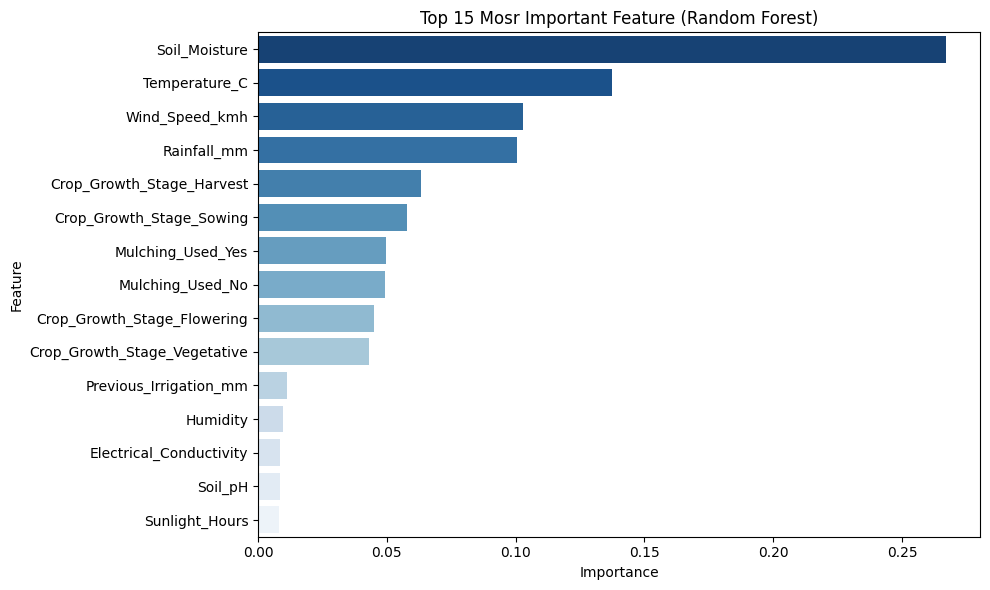

In [33]:
feature_names = (
    numeric_variables +
    model.named_steps['preprocessing']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_variables)
    .tolist()
)

importances = model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', legend=False, palette='Blues_r')
plt.title('Top 15 Mosr Important Feature (Random Forest)')
plt.tight_layout()
plt.show()

The model's top features align well with our EDA findings — Soil_Moisture and Temperature_C dominate, confirming their visual class separation. Crop_Growth_Stage also ranks highly among categoricals, consistent with our crosstab analysis

## Applying model to Kaggle Test Set
We now apply the trained model to the official Kaggle test set and generate a submission file

In [34]:
kaggle_test= pd.read_csv("Dataset/test.csv")

kaggle_preds= model.predict(kaggle_test.drop('id', axis=1))

submission= pd.DataFrame({
    'id': kaggle_test['id'],
    'Irrigation_Need': kaggle_preds
})

submission.to_csv("submission.csv", index= False)
print('Submission.csv saved successfully!')
display(submission.head)

Submission.csv saved successfully!


<bound method NDFrame.head of             id Irrigation_Need
0       630000             Low
1       630001             Low
2       630002             Low
3       630003             Low
4       630004             Low
...        ...             ...
269995  899995          Medium
269996  899996             Low
269997  899997          Medium
269998  899998             Low
269999  899999          Medium

[270000 rows x 2 columns]>

### Kaggle Submission Score

The generated `submission.csv` was submitted to the **Predicting Irrigation Need** 
Kaggle competition.

| Attempt | Model | Score |
|---------|-------|-------|
| 1 | Random Forest (default params) | 0.95290 |
| 2 | Random Forest (tuned) | 0.95798 |

**Best Score:** 0.95798  
**Metric:** Balanced Accuracy   
**Percentile:** Top 17%     
**Competition Size:** 6,864 entrants, 33,415 total submissions   
**Improvement:** +0.00508 over baseline through hyperparameter tuning

### Key Findings
- **Soil_Moisture** and **Temperature_C** were the strongest predictors, both in EDA and confirmed by the model's feature importance
- **Crop_Growth_Stage** emerged as the most important categorical feature, consistent with the crosstab analysis
- Class imbalance (High class: 3.33%) was effectively managed using `class_weight='balanced'`, allowing the model to meaningfully predict the minority class.
The primary remaining weakness is a small number of `Low` cases misclassified as `High` (~10% of that class), which could be addressed in future work through threshold tuning or additional feature engineering

### Conclusion
A tuned `RandomForestClassifier` wrapped in a full sklearn `Pipeline` achieved strong and consistent performance across all evaluation sets, placing in the top 17% of the Kaggle competition. The model's learned feature importances closely matched the patterns identified during exploratory data analysis, validating the end-to-end workflow from data exploration through to submission.